<a href="https://colab.research.google.com/github/gracy2004/gr/blob/main/housing_price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**House Price
Prediction (Regression)**

**Problem Statement**

The real estate industry often needs accurate estimation of property prices based on various
house characteristics. In this task, the goal is to build a Machine Learning regression model
that predicts the price of a house using features such as house size, number of bedrooms,
number of bathrooms, lot size, garage size, neighborhood quality, and the year the house was
built.
Students are required to analyze the dataset, perform data preprocessing, apply feature
engineering techniques, train multiple regression models, and evaluate their performance to
identify the best model for predicting house prices.

In [25]:
#Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [26]:
#load dataset
df = pd.read_csv('house price.csv')
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [27]:
#Check Dataset
df.shape

(1000, 8)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [29]:
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [30]:
#Handle Missing Values
df.isnull().sum()

,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


In [31]:
#if null then drop
df = df.dropna()

In [32]:
#Remove Duplicate Records
df.duplicated().sum()

np.int64(0)

In [33]:
df = df.drop_duplicates()

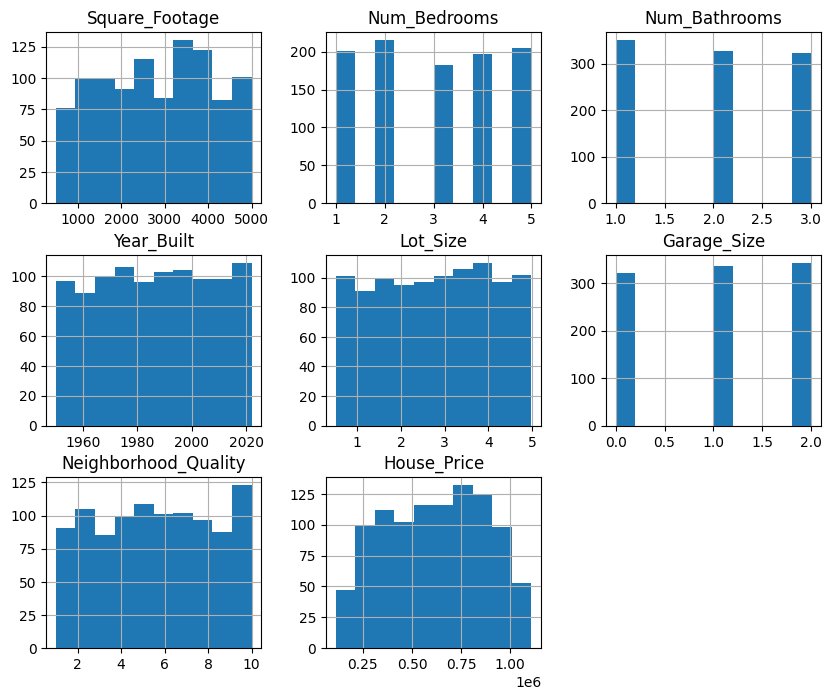

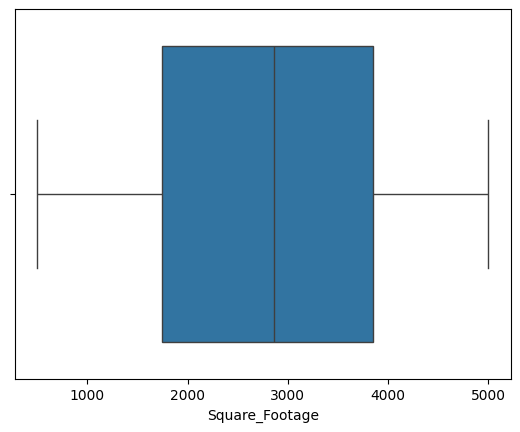

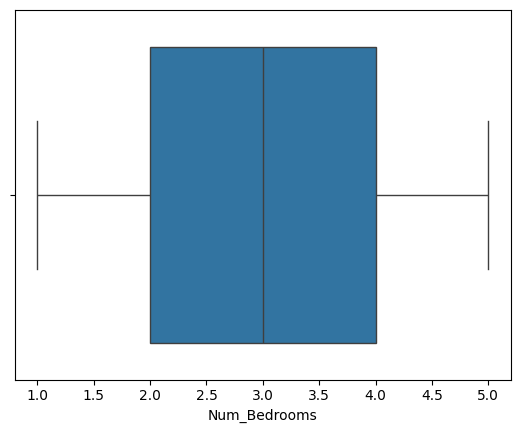

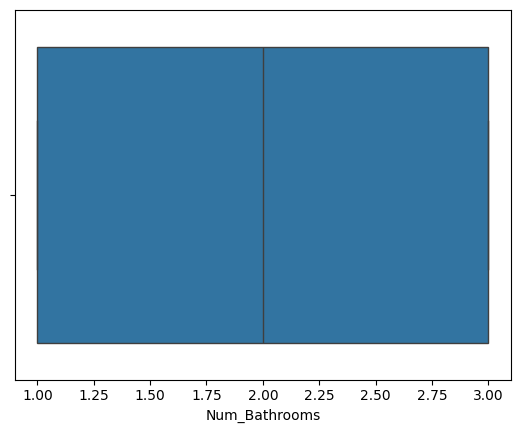

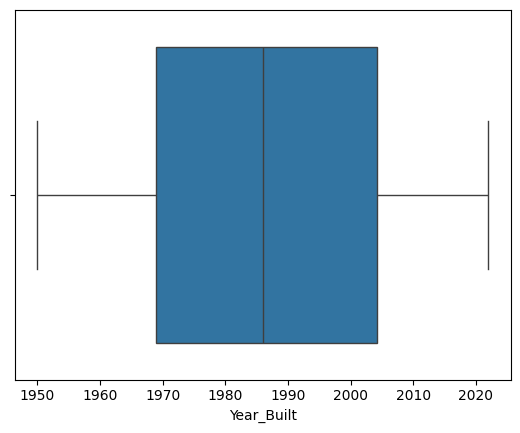

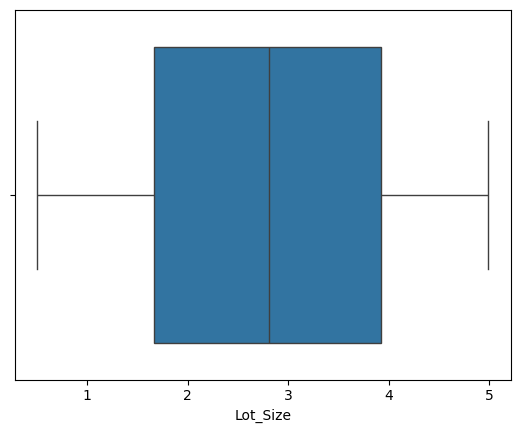

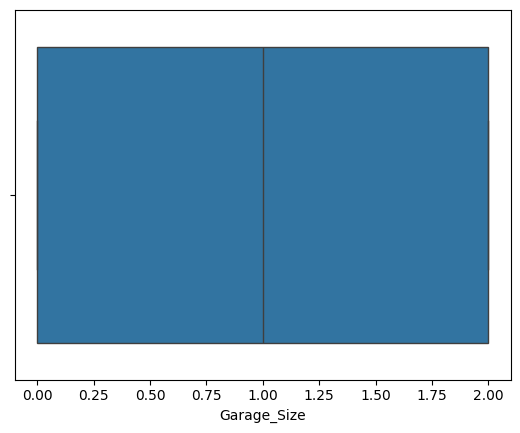

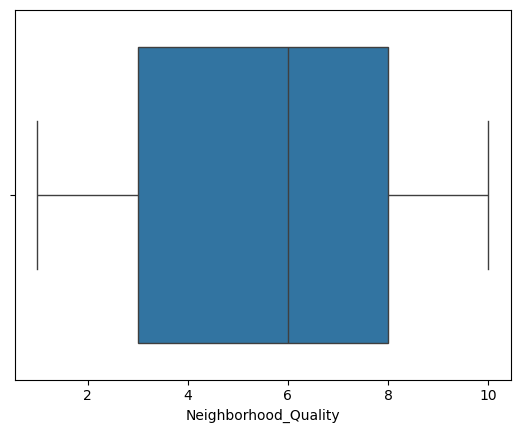

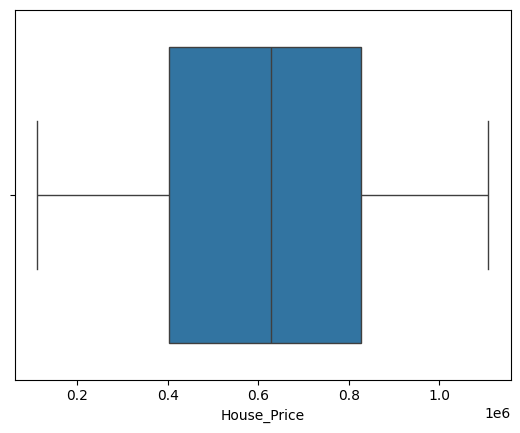

In [34]:
#Univariate Analysis
df.hist(figsize=(10,8))
plt.show()
for col in df.columns:
    sns.boxplot(x=df[col])
    plt.show()

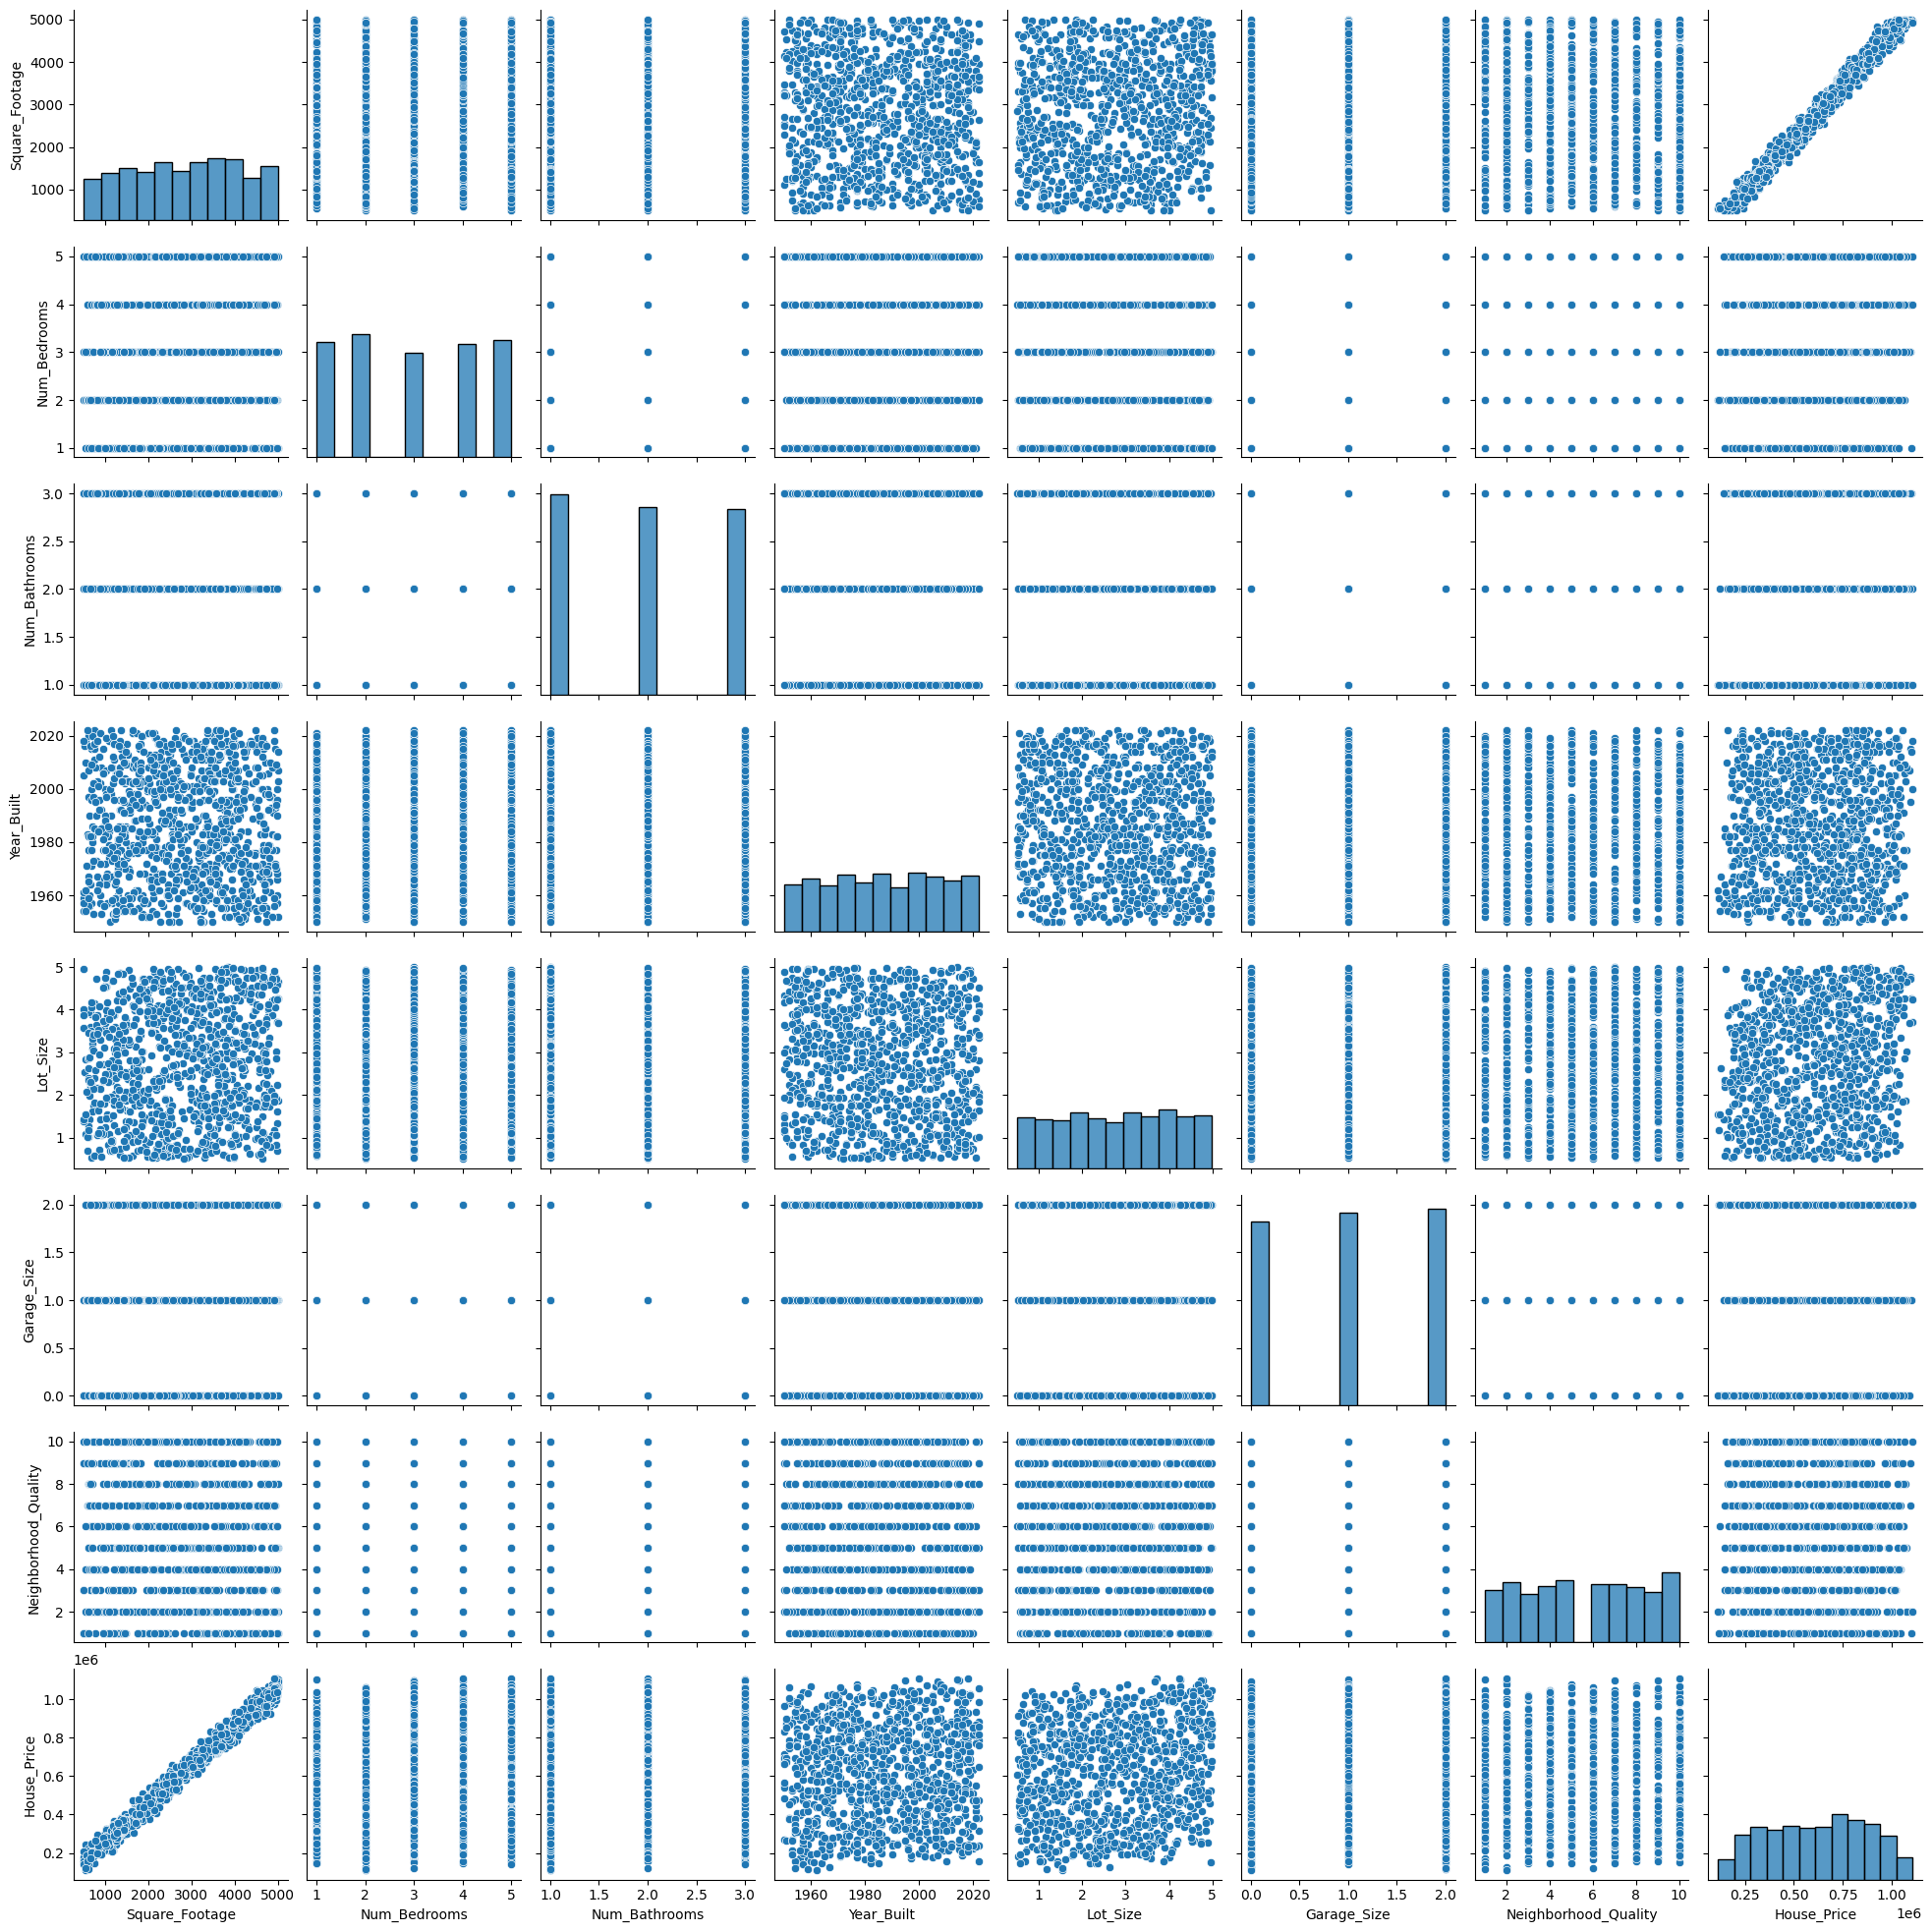

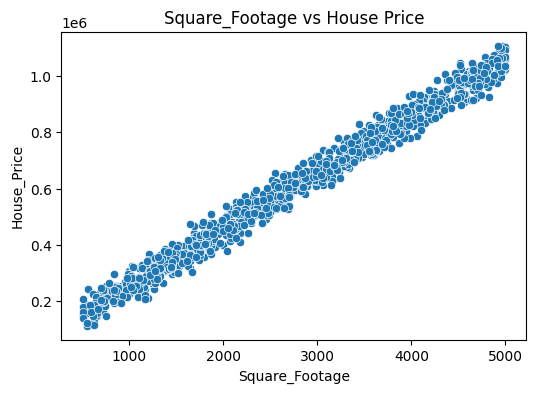

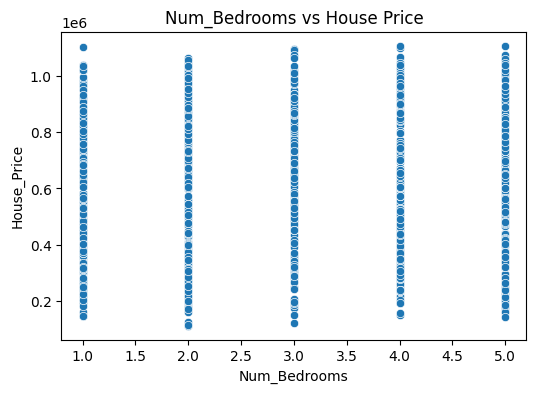

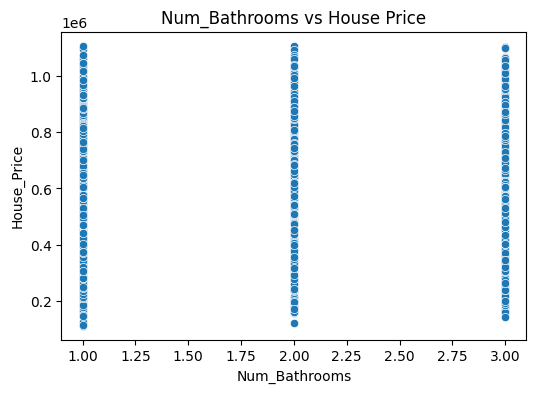

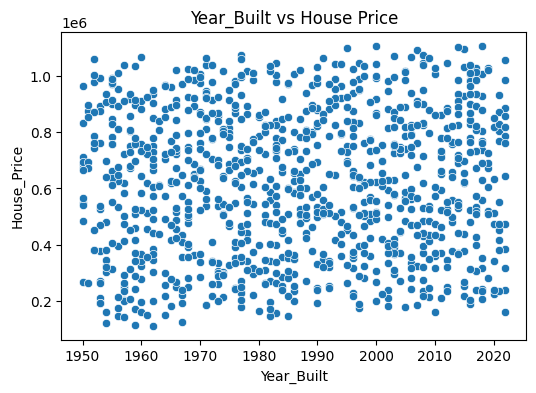

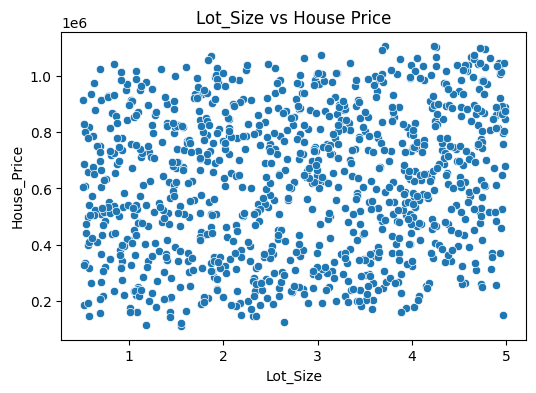

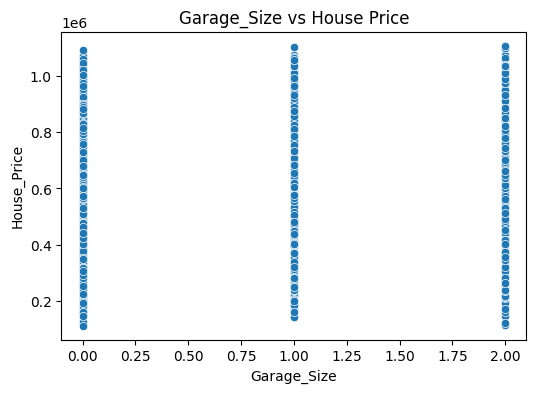

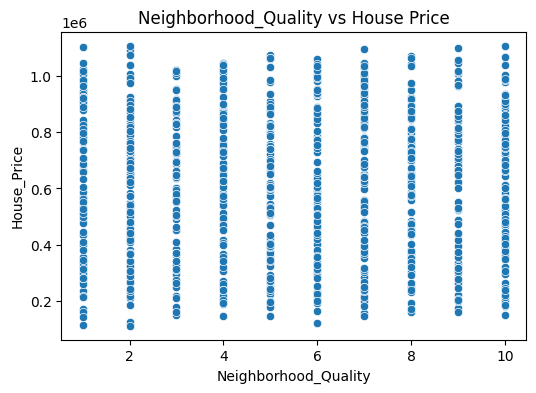

In [11]:
#Bivariate Analysis
sns.pairplot(df)
plt.show()
features = df.drop('House_Price', axis=1).columns

for col in features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col], y=df['House_Price'])
    plt.title(f'{col} vs House Price')
    plt.show()

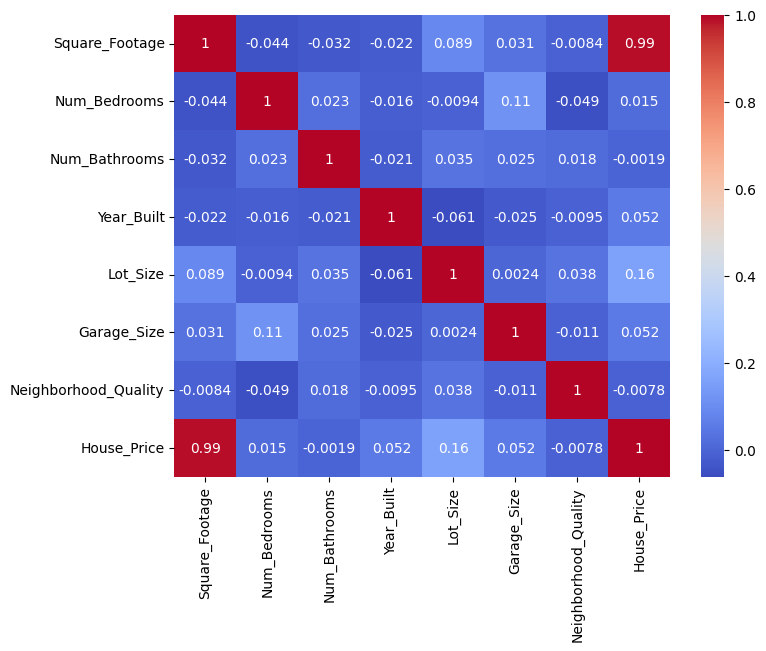

In [12]:
#Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

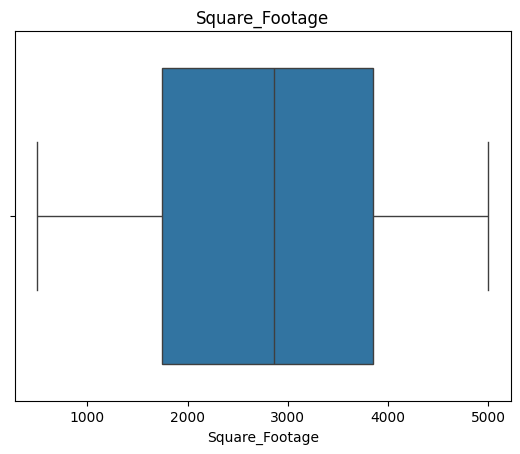

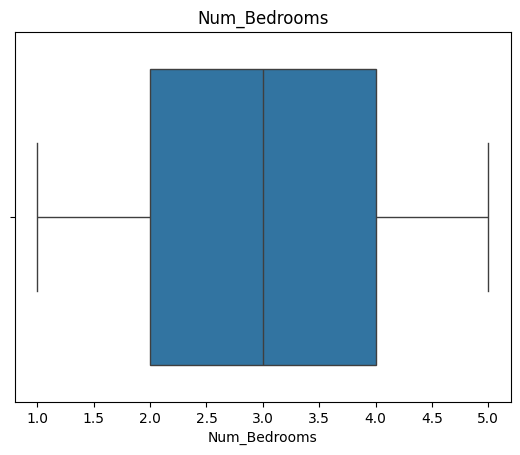

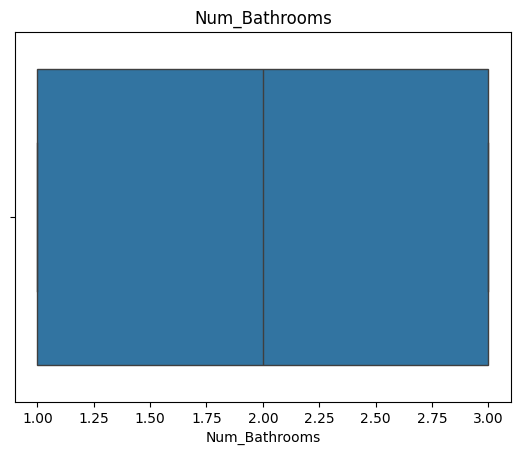

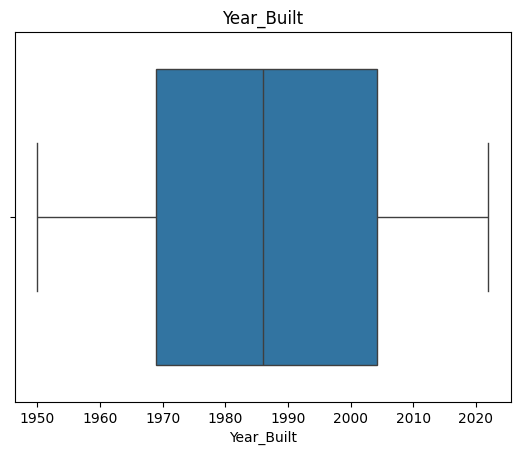

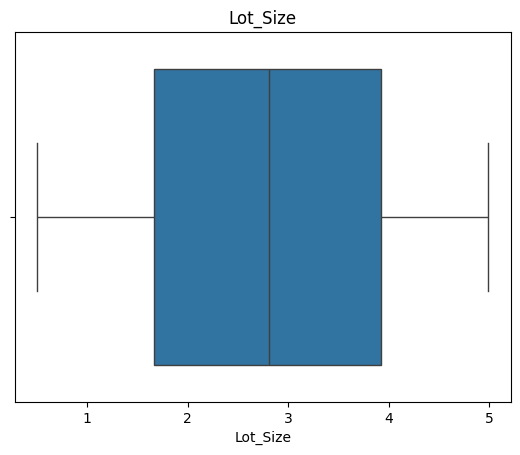

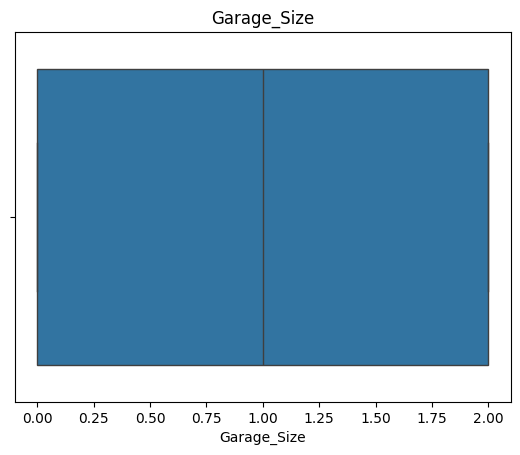

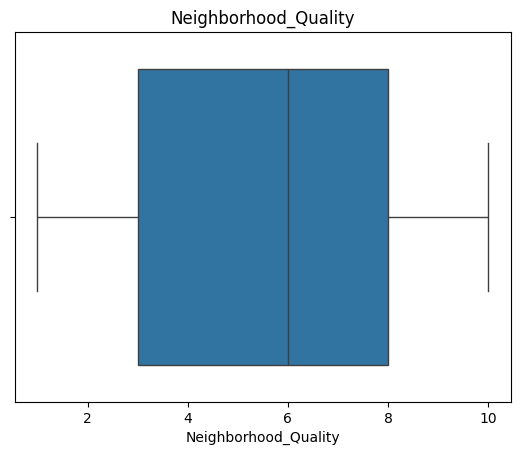

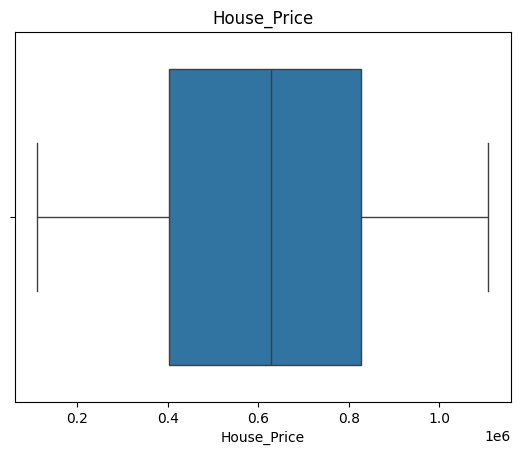

In [13]:
#Detect Outliers
for col in df.columns:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()
    Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) |(df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [14]:
# Encoding categorical variables
df = pd.get_dummies(df, drop_first=True)

In [15]:
#Log Transformation
df['House_Price'] = np.log(df['House_Price'])

In [16]:
#Separate Features and Target
X = df.drop('House_Price', axis=1)
y = df['House_Price']

In [17]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
#Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
#Train Models
#Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [20]:
#KNN Regression
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [21]:
#Evaluation Metrics
#Linear Regression
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_lr)
mape = np.mean(np.abs((y_test - y_pred_lr) / y_test)) * 100
n = X_test.shape[0]
p = X_test.shape[1]
adj_r2 = 1 - (1-r2)*(n-1)/(n-p-1)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAPE:", mape)
print("R2:", r2)
print("Adjusted R2:", adj_r2)


MAE: 0.09078292767761202
MSE: 0.012923132230239545
RMSE: 0.11367995527022143
MAPE: 0.695987033882357
R2: 0.9462493474741257
Adjusted R2: 0.9442896882674532


In [22]:
#KNN Regression
mae = mean_absolute_error(y_test, y_pred_knn)
mse = mean_squared_error(y_test, y_pred_knn)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_knn)
mape = np.mean(np.abs((y_test - y_pred_knn) / y_test)) * 100
n = X_test.shape[0]
p = X_test.shape[1]
adj_r2 = 1 - (1-r2)*(n-1)/(n-p-1)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAPE:", mape)
print("R2:", r2)
print("Adjusted R2:", adj_r2)


MAE: 0.13352458657348393
MSE: 0.03275242370493434
RMSE: 0.18097630702645676
MAPE: 1.0316078365784032
R2: 0.8637741907627683
Adjusted R2: 0.8588076248009943


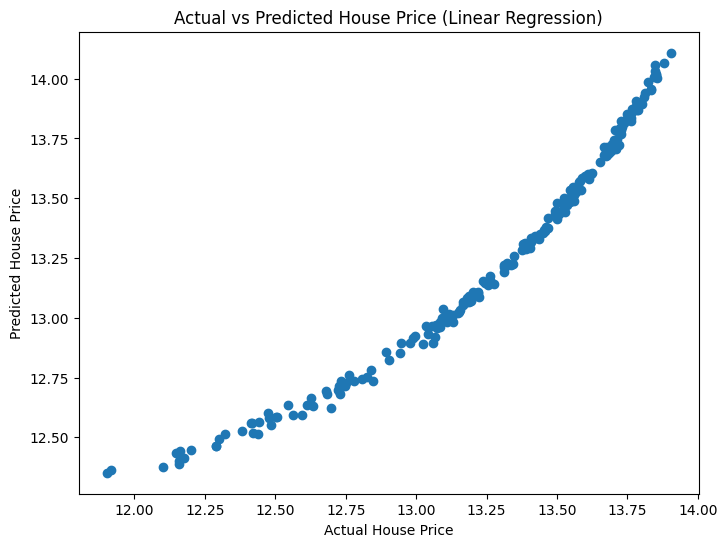

In [23]:
#final graph
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Price (Linear Regression)")
plt.show()

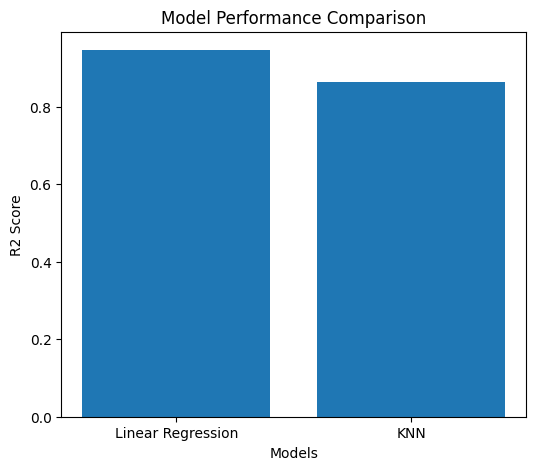

In [24]:
#comparison of models
models = ['Linear Regression','KNN']
r2_scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_knn)
]
plt.figure(figsize=(6,5))
plt.bar(models, r2_scores)
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.title("Model Performance Comparison")
plt.show()